In [ ]:
# Package imports
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

def initialize_parameters_deep(layer_dims):

    np.random.seed(3)
    parameters = {}
    L = len(layer_dims) # number of layers in the network

    for l in range(1, L):

        parameters['W' + str(l)] = np.random.randn(layer_dims[l], layer_dims[l-1])*1
        parameters['b'+str(l)] = np.zeros((layer_dims[l], 1))

        assert(parameters['W' + str(l)].shape == (layer_dims[l], layer_dims[l - 1]))
        assert(parameters['b' + str(l)].shape == (layer_dims[l], 1))

    return parameters


In [ ]:
#XOR data
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])  # Shape: (4, 2)
Y = np.array([[0, 1, 1, 0]])              # Shape: (4, 1)


In [ ]:
def sigmoid(Z):
    A = 1/(1+np.exp(-Z))
    cache = Z
    return A, cache  # Return Output first, then Cache

In [ ]:
def relu(Z):
    A = np.maximum(0,Z)
    cache = Z
    return A, cache # Return Output first, then : ∂W∂z​=aprevT​. So, dW=dz⋅aprevT​Cache

In [ ]:
def linear_forward(A, W, b):
    Z = np.dot(W, A)+b
    cache = (A, W, b)
    return Z, cache



In [ ]:

def linear_activation_forward(A_prev, W, b, activation):
    """
    Implement the forward propagation for the LINEAR->ACTIVATION layer
    """
    if activation == "sigmoid":

        Z,linear_cache = linear_forward(A_prev, W, b)
        A, activation_cache = sigmoid(Z)

    elif activation == "relu":

        Z,linear_cache = linear_forward(A_prev, W, b)
        A, activation_cache = relu(Z)

    cache = (linear_cache, activation_cache)



    return A, cache

In [ ]:
def L_model_forward(X, parameters, hidden_activation="sigmoid"):
    """
    Forward propagation through the network

    Arguments:
    X -- input data, shape (input size, number of examples)
    parameters -- output of initialize_parameters_deep()
    hidden_activation -- "relu" for MNIST, "sigmoid" for XOR

    Returns:
    AL -- output of the last layer (predictions)
    caches -- list of caches for backward propagation
    """
    caches = []
    A = X
    L = len(parameters) // 2  # number of layers

    # Hidden layers
    for l in range(1, L):
        A_prev = A
        A, cache = linear_activation_forward(A_prev, parameters["W" + str(l)],
                                             parameters["b" + str(l)], hidden_activation)
        caches.append(cache)

    # Output layer (always sigmoid for binary classification)
    AL, cache = linear_activation_forward(A, parameters["W" + str(L)],
                                          parameters["b" + str(L)], "sigmoid")
    caches.append(cache)

    return AL, caches


In [ ]:
def compute_cost(AL, Y):
    m = Y.shape[1]

    # Check if binary or multi-class
    if Y.shape[0] == 1:  # Binary classification
        epsilon = 1e-8
        AL = np.clip(AL, epsilon, 1 - epsilon)
        cost = -1/m * np.sum(Y*np.log(AL) + (1-Y)*np.log(1-AL))
    else:  # Multi-class classification (MNIST)
        epsilon = 1e-8
        AL = np.clip(AL, epsilon, 1 - epsilon)
        cost = -1/m * np.sum(Y * np.log(AL))

    cost = np.squeeze(cost)
    return cost


In [ ]:

def linear_backward(dZ, cache):
    """
    Implement the linear portion of backward propagation for a single layer (layer l)

    Arguments:
    dZ -- Gradient of the cost with respect to the linear output (of current layer l)
    cache -- tuple of values (A_prev, W, b) coming from the forward propagation in the current layer

    Returns:
    dA_prev -- Gradient of the cost with respect to the activation (of the previous layer l-1), same shape as A_prev
    dW -- Gradient of the cost with respect to W (current layer l), same shape as W
    db -- Gradient of the cost with respect to b (current layer l), same shape as b
    """
    A_prev, W, b = cache
    m = A_prev.shape[1]


    dW = 1/m* np.dot(dZ,A_prev.T)
    db = 1/m*np.sum(dZ,axis=1, keepdims=True)# Calculate gradient of cost with respect to b
    dA_prev = np.dot(W.T, dZ)


    return dA_prev, dW, db



In [ ]:
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

# Load dataset (as shown in PDF)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Inspect dimensions
print("Training set:", X_train.shape)  # (60000, 28, 28)
print("Test set:", X_test.shape)        # (10000, 28, 28)
print("Pixel range:", X_train.min(), "to", X_train.max())  # 0 to 255

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training set: (60000, 28, 28)
Test set: (10000, 28, 28)
Pixel range: 0 to 255


In [ ]:

def sigmoid_backward(dA, activation_cache):
    """
    Compute derivative for sigmoid activation
    Derivative: σ'(Z) = σ(Z) * (1 - σ(Z))
    """
    Z = activation_cache

    # Compute sigmoid of Z
    A = 1 / (1 + np.exp(-Z))

    # Compute dZ = dA * sigmoid'(Z)
    dZ = dA * A * (1 - A)

    return dZ



In [ ]:
def relu_backward(dA, activation_cache):
    """
    Compute derivative for ReLU activation
    Derivative: ReLU'(Z) = 1 if Z > 0, else 0
    """
    Z = activation_cache

    # Create a copy to avoid modifying original
    dZ = np.array(dA, copy=True)

    # When Z <= 0, gradient is 0
    dZ[Z <= 0] = 0

    return dZ


In [ ]:

def linear_activation_backward(dA, cache, activation):
    """
    Backward propagation for the LINEAR->ACTIVATION layer.
    """
    linear_cache, activation_cache = cache

    if activation == "sigmoid":

        dZ = sigmoid_backward(dA, activation_cache)# Compute gradient of the linear part (dZ) from the activation gradient (dA)
        dA_prev, dW, db = linear_backward(dZ, linear_cache )# Compute gradients of the layer parameters (dW, db) and previous activation (dA_prev)

    if activation == "relu":

        dZ = relu_backward(dA, activation_cache)# Compute gradient of the linear part (dZ) from the activation gradient (dA)
        dA_prev, dW, db = linear_backward(dZ, linear_cache )# Compute gradients of the layer parameters (dW, db) and previous activation (dA_prev)

    return dA_prev, dW, db

In [ ]:
def L_model_backward(AL, Y, caches, hidden_activation="sigmoid"):

    grads = {}
    L = len(caches)  # number of layers
    m = AL.shape[1]
    Y = Y.reshape(AL.shape)  # ensure Y has same shape as AL

    # Derivative of cost with respect to AL
    epsilon = 1e-8
    dAL = - (np.divide(Y, AL + epsilon) - np.divide(1 - Y, 1 - AL + epsilon))
    # Output layer (sigmoid) gradients
    current_cache = caches[L-1]
    dA_prev_temp, dW_temp, db_temp = linear_activation_backward(dAL, current_cache, "sigmoid")
    grads["dA" + str(L-1)] = dA_prev_temp
    grads["dW" + str(L)] = dW_temp
    grads["db" + str(L)] = db_temp

    # Hidden layers gradients
    for l in reversed(range(L-1)):
        current_cache = caches[l]
        dA_prev_temp, dW_temp, db_temp = linear_activation_backward(grads["dA" + str(l + 1)], current_cache, hidden_activation)
        grads["dA" + str(l)] = dA_prev_temp
        grads["dW" + str(l + 1)] = dW_temp
        grads["db" + str(l + 1)] = db_temp

    return grads


In [ ]:

def update_parameters(params, grads, learning_rate):
    """
    Update parameters using gradient descent

    Arguments:
    params -- python dictionary containing your parameters
    grads -- python dictionary containing your gradients, output of L_model_backward

    Returns:
    parameters -- python dictionary containing your updated parameters
                  parameters["W" + str(l)] = ...
                  parameters["b" + str(l)] = ...
    """

    L = len(params) // 2 # number of layers in the neural network


    for l in range(L):

        params["W" + str(l+1)] =  params["W" + str(l+1)]- learning_rate*grads["dW" +str(l+1)]
        params["b" + str(l+1)] =  params["b" + str(l+1)]- learning_rate*grads["db" +str(l+1)]

    return params

In [ ]:
def L_layer_model(X, Y, layers_dims, learning_rate=0.01, num_iterations=3000,
                  print_cost=True, hidden_activation="sigmoid"):
    """
    Implements an L-layer neural network.

    Arguments:
    X -- input data, shape (input size, number of examples)
    Y -- true labels, shape (1, number of examples)
    layers_dims -- list containing dimensions of each layer
    learning_rate -- learning rate for gradient descent
    num_iterations -- number of iterations
    print_cost -- if True, print cost every 100 iterations
    hidden_activation -- "relu" for MNIST, "sigmoid" for XOR

    Returns:
    parameters -- learned parameters
    costs -- list of costs during training
    """
    np.random.seed(1)
    costs = []

    # Initialize parameters
    parameters = initialize_parameters_deep(layers_dims)

    # Training loop
    for i in range(0, num_iterations):

        # Forward propagation
        AL, caches = L_model_forward(X, parameters, hidden_activation)

        # Compute cost
        cost = compute_cost(AL, Y)

        # Backward propagation
        grads = L_model_backward(AL, Y, caches, hidden_activation)

        # Update parameters
        parameters = update_parameters(parameters, grads, learning_rate)

        # Print and store cost
        if print_cost and (i % 100 == 0 or i == num_iterations - 1):
            print("Cost after iteration {}: {}".format(i, np.squeeze(cost)))
        if i % 100 == 0:
            costs.append(cost)

    return parameters, costs


In [ ]:
def dictionary_to_vector(parameters):
    """
    Roll all our parameters dictionary into a single vector satisfying our specific required shape.
    """
    keys = []
    count = 0
    for l in range(1, len(parameters) // 2 + 1):
        for key in ['W' + str(l), 'b' + str(l)]:
            new_vector = np.reshape(parameters[key], (-1, 1))
            keys = keys + [key] * new_vector.shape[0]
            if count == 0:
                theta = new_vector
            else:
                theta = np.concatenate((theta, new_vector), axis=0)
            count = count + 1
    return theta, keys

def vector_to_dictionary(theta, layer_dims):
    """
    Unroll a variable "theta" into a dictionary of parameters.
    """
    parameters = {}
    L = len(layer_dims)
    start = 0
    for l in range(1, L):
        end_W = start + layer_dims[l] * layer_dims[l-1]
        parameters['W' + str(l)] = theta[start:end_W].reshape((layer_dims[l], layer_dims[l-1]))

        start_b = end_W
        end_b = start_b + layer_dims[l]
        parameters['b' + str(l)] = theta[start_b:end_b].reshape((layer_dims[l], 1))

        start = end_b
    return parameters

def gradients_to_vector(gradients):
    """
    Roll all our gradients dictionary into a single vector.
    """
    count = 0
    # Note: iterating backwards to match the order used in dictionary_to_vector
    # but based on layer number for consistency
    L = len(gradients) // 3
    for l in range(1, L + 1):
        for key in ['dW' + str(l), 'db' + str(l)]:
            new_vector = np.reshape(gradients[key], (-1, 1))
            if count == 0:
                theta = new_vector
            else:
                theta = np.concatenate((theta, new_vector), axis=0)
            count = count + 1
    return theta

In [ ]:
def gradient_check_n(parameters, gradients, X, Y, epsilon=1e-7):
    # Set-up variables
    parameters_values, _ = dictionary_to_vector(parameters)
    grad = gradients_to_vector(gradients)
    num_parameters = parameters_values.shape[0]
    J_plus = np.zeros((num_parameters, 1))
    J_minus = np.zeros((num_parameters, 1))
    gradapprox = np.zeros((num_parameters, 1))

    # Get layer_dims for the vector_to_dictionary helper
    layer_dims = []
    layer_dims.append(X.shape[0])
    for l in range(1, len(parameters) // 2 + 1):
        layer_dims.append(parameters['W' + str(l)].shape[0])

    # Compute gradapprox
    for i in range(num_parameters):
        # Compute J_plus[i]
        thetaplus = np.copy(parameters_values)
        thetaplus[i][0] = thetaplus[i][0] + epsilon
        AL_plus, _ = L_model_forward(X, vector_to_dictionary(thetaplus, layer_dims), hidden_activation="sigmoid")
        J_plus[i] = compute_cost(AL_plus, Y)

        # Compute J_minus[i]
        thetaminus = np.copy(parameters_values)
        thetaminus[i][0] = thetaminus[i][0] - epsilon
        AL_minus, _ = L_model_forward(X, vector_to_dictionary(thetaminus, layer_dims), hidden_activation="sigmoid")
        J_minus[i] = compute_cost(AL_minus, Y)

        # Compute gradapprox[i]
        gradapprox[i] = (J_plus[i] - J_minus[i]) / (2 * epsilon)

    # Compare gradapprox to backward propagation gradients by computing difference.
    numerator = np.linalg.norm(grad - gradapprox)
    denominator = np.linalg.norm(grad) + np.linalg.norm(gradapprox)
    difference = numerator / denominator

    if difference < 1e-7:
        print("The gradient check passed! Difference = " + str(difference))
    else:
        print("The gradient check failed! Difference = " + str(difference))

    return difference

In [ ]:
# 1. Initialize
layers_dims = [2, 4, 1]
parameters = initialize_parameters_deep(layers_dims)

# 2. Forward and Backward pass
AL, caches = L_model_forward(X.T, parameters,"sigmoid")
gradients = L_model_backward(AL, Y, caches)

# 3. Check gradients
difference = gradient_check_n(parameters, gradients, X.T, Y)

The gradient check passed! Difference = 2.1507902604439364e-08


TRAINING XOR MODEL
Cost after iteration 0: 0.712185740306757
Cost after iteration 100: 0.692535771719532
Cost after iteration 200: 0.6918308759131842
Cost after iteration 300: 0.691102372347184
Cost after iteration 400: 0.6902866486545367
Cost after iteration 500: 0.6893199093693163
Cost after iteration 600: 0.6881314106769706
Cost after iteration 700: 0.6866384022357346
Cost after iteration 800: 0.6847425659240007
Cost after iteration 900: 0.6823287843836469
Cost after iteration 1000: 0.6792677919431169
Cost after iteration 1100: 0.6754245831010464
Cost after iteration 1200: 0.6706736639264903
Cost after iteration 1300: 0.6649196636794077
Cost after iteration 1400: 0.6581179978843911
Cost after iteration 1500: 0.6502876390412211
Cost after iteration 1600: 0.6415096033506973
Cost after iteration 1700: 0.6319110470392081
Cost after iteration 1800: 0.6216420687314897
Cost after iteration 1900: 0.6108545125693123
Cost after iteration 2000: 0.5996877360450514
Cost after iteration 2100: 0.5

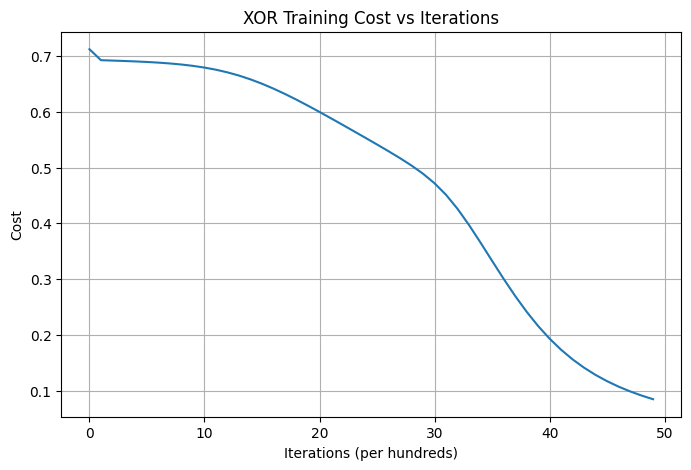

In [ ]:


# Train XOR model
print("="*50)
print("TRAINING XOR MODEL")
print("="*50)

layers_dims_xor = [2, 4, 1]
parameters_xor, costs_xor = L_layer_model(X.T, Y, layers_dims_xor,
                                           learning_rate=0.1,
                                           num_iterations=5000,
                                           print_cost=True,
                                           hidden_activation="sigmoid")

# Make predictions for XOR
AL_xor, _ = L_model_forward(X.T, parameters_xor, hidden_activation="sigmoid")
predicted_labels = (AL_xor >= 0.5).astype(int)

# Calculate accuracy
correct = np.sum(predicted_labels == Y)
accuracy = (correct / Y.shape[1]) * 100

print("="*50)
print("XOR RESULTS")
print("="*50)
print(f"Predictions: {predicted_labels.flatten()}")
print(f"True labels: {Y.flatten()}")
print(f"Accuracy: {accuracy:.1f}%")
print(f"Target >95%: {'PASSED' if accuracy > 95 else 'FAILED'}")

# Plot training curve
plt.figure(figsize=(8, 5))
plt.plot(costs_xor)
plt.ylabel('Cost')
plt.xlabel('Iterations (per hundreds)')
plt.title('XOR Training Cost vs Iterations')
plt.grid(True)
plt.show()


In [ ]:


def softmax(Z):
    """
    Softmax activation function for multi-class classification
    """
    # Subtract max for numerical stability
    exp_Z = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    A = exp_Z / np.sum(exp_Z, axis=0, keepdims=True)
    cache = Z
    return A, cache


In [ ]:

# Preprocess MNIST data
X_train_flat = X_train.reshape(X_train.shape[0], -1).T  # (784, 60000)
X_test_flat = X_test.reshape(X_test.shape[0], -1).T     # (784, 10000)

# Normalize pixel values to [0, 1]
X_train_flat = X_train_flat / 255.0
X_test_flat = X_test_flat / 255.0

# Convert labels to one-hot encoding for 10 classes
def one_hot_encode(y, num_classes=10):
    one_hot = np.zeros((num_classes, y.shape[0]))
    one_hot[y, np.arange(y.shape[0])] = 1
    return one_hot

Y_train = one_hot_encode(y_train)  # (10, 60000)
Y_test = one_hot_encode(y_test)    # (10, 10000)

print(f"X_train_flat shape: {X_train_flat.shape}")
print(f"Y_train shape: {Y_train.shape}")


X_train_flat shape: (784, 60000)
Y_train shape: (10, 60000)


In [ ]:
def initialize_parameters_MNIST(layer_dims):

    np.random.seed(3)
    parameters = {}
    L = len(layer_dims) # number of layers in the network

    for l in range(1, L):

        parameters['W' + str(l)] = np.random.randn(layer_dims[l], layer_dims[l-1])*0.01
        parameters['b'+str(l)] = np.zeros((layer_dims[l], 1))

        assert(parameters['W' + str(l)].shape == (layer_dims[l], layer_dims[l - 1]))
        assert(parameters['b' + str(l)].shape == (layer_dims[l], 1))

    return parameters

In [ ]:
def L_model_forward_MNIST(X, parameters, hidden_activation="relu"):
    """
    MNIST-specific forward propagation with softmax output.
    Separate from XOR version to avoid breaking working code.
    """
    caches = []
    A = X
    L = len(parameters) // 2  # number of layers

    # Hidden layers
    for l in range(1, L):
        A_prev = A
        A, cache = linear_activation_forward(A_prev, parameters["W" + str(l)],
                                            parameters["b" + str(l)], hidden_activation)
        caches.append(cache)

    # Output layer - ALWAYS use softmax for MNIST (10 classes)
    Z, linear_cache = linear_forward(A, parameters["W" + str(L)],
                                     parameters["b" + str(L)])
    AL, activation_cache = softmax(Z)

    cache = (linear_cache, activation_cache)
    caches.append(cache)

    return AL, caches


In [ ]:
def L_model_backward_MNIST(AL, Y, caches, hidden_activation="relu"):
    """
    MNIST-specific backward propagation with softmax gradient.
    Separate from XOR version to avoid breaking working code.
    """
    grads = {}
    L = len(caches)  # number of layers
    m = AL.shape[1]
    Y = Y.reshape(AL.shape)  # ensure Y has same shape as AL

    # For softmax + cross-entropy, gradient is simply: AL - Y
    dZ_output = AL - Y

    # Output layer gradients (manual computation for softmax)
    linear_cache, activation_cache = caches[L-1]
    A_prev, W, b = linear_cache
    dAprev_temp, dW_temp, db_temp = linear_backward(dZ_output, linear_cache)

    grads["dA" + str(L-1)] = dAprev_temp
    grads["dW" + str(L)] = dW_temp
    grads["db" + str(L)] = db_temp

    # Hidden layers gradients (same as before)
    for l in reversed(range(L-1)):
        current_cache = caches[l]
        dAprev_temp, dW_temp, db_temp = linear_activation_backward(grads["dA" + str(l + 1)], current_cache, hidden_activation)
        grads["dA" + str(l)] = dAprev_temp
        grads["dW" + str(l + 1)] = dW_temp
        grads["db" + str(l + 1)] = db_temp

    return grads


In [ ]:
# PART B: TRAIN MNIST MODEL WITH MINI-BATCHES


def random_mini_batches(X, Y, mini_batch_size=25, seed=0):
    """
    Creates a list of random mini-batches from (X, Y)
    """
    np.random.seed(seed)
    m = X.shape[1]  # number of training examples
    mini_batches = []

    # Shuffle (X, Y)
    permutation = list(np.random.permutation(m))
    shuffled_X = X[:, permutation]
    shuffled_Y = Y[:, permutation]

    # Partition (shuffled_X, shuffled_Y). Minus the end case.
    num_complete_minibatches = m // mini_batch_size

    for k in range(num_complete_minibatches):
        mini_batch_X = shuffled_X[:, k * mini_batch_size:(k + 1) * mini_batch_size]
        mini_batch_Y = shuffled_Y[:, k * mini_batch_size:(k + 1) * mini_batch_size]
        mini_batch = (mini_batch_X, mini_batch_Y)
        mini_batches.append(mini_batch)

    # Handle the end case (last mini-batch < mini_batch_size)
    if m % mini_batch_size != 0:
        mini_batch_X = shuffled_X[:, num_complete_minibatches * mini_batch_size:]
        mini_batch_Y = shuffled_Y[:, num_complete_minibatches * mini_batch_size:]
        mini_batch = (mini_batch_X, mini_batch_Y)
        mini_batches.append(mini_batch)

    return mini_batches


# Training with mini-batches and epochs
print("="*50)
print("TRAINING MNIST MODEL WITH MINI-BATCHES")
print("="*50)

layers_dims_MNIST = [784, 128,64, 10]
parameters_MNIST = initialize_parameters_MNIST(layers_dims_MNIST)

learning_rate = .1
num_epochs = 20  # Maximum 20 epochs as required
mini_batch_size = 25  # Batch size as required
costs_MNIST = []

np.random.seed(1)

# Use full training set (or subset if needed for speed)
X_train_full = X_train_flat[:, :60000]  # Use 60k for reasonable speed
Y_train_full = Y_train[:, :60000]

for epoch in range(num_epochs):
    epoch_cost = 0.
    num_minibatches = 0

    # Get mini-batches
    minibatches = random_mini_batches(X_train_full, Y_train_full,
                                      mini_batch_size, seed=epoch)

    for minibatch in minibatches:
        (minibatch_X, minibatch_Y) = minibatch

        # Forward propagation
        AL_MNIST, caches_MNIST = L_model_forward_MNIST(minibatch_X, parameters_MNIST,
                                                        hidden_activation="relu")

        # Compute cost
        cost_MNIST = compute_cost(AL_MNIST, minibatch_Y)

        # Backward propagation
        grads_MNIST = L_model_backward_MNIST(AL_MNIST, minibatch_Y, caches_MNIST,
                                             hidden_activation="relu")

        # Update parameters
        parameters_MNIST = update_parameters(parameters_MNIST, grads_MNIST, learning_rate)

        epoch_cost += cost_MNIST
        num_minibatches += 1

    # Print average cost per epoch
    avg_cost = epoch_cost / num_minibatches
    costs_MNIST.append(avg_cost)
    print(f"Epoch {epoch+1}/{num_epochs}, Cost: {avg_cost:.4f}")

print("="*50)
print("MNIST training complete!")


TRAINING MNIST MODEL WITH MINI-BATCHES
Epoch 1/20, Cost: 0.7030
Epoch 2/20, Cost: 0.1527
Epoch 3/20, Cost: 0.1017
Epoch 4/20, Cost: 0.0763
Epoch 5/20, Cost: 0.0605
Epoch 6/20, Cost: 0.0480
Epoch 7/20, Cost: 0.0414
Epoch 8/20, Cost: 0.0332
Epoch 9/20, Cost: 0.0279
Epoch 10/20, Cost: 0.0217
Epoch 11/20, Cost: 0.0174
Epoch 12/20, Cost: 0.0154
Epoch 13/20, Cost: 0.0127
Epoch 14/20, Cost: 0.0127
Epoch 15/20, Cost: 0.0093
Epoch 16/20, Cost: 0.0101
Epoch 17/20, Cost: 0.0075
Epoch 18/20, Cost: 0.0031
Epoch 19/20, Cost: 0.0013
Epoch 20/20, Cost: 0.0008
MNIST training complete!


In [ ]:

# EVALUATE MNIST MODEL


print("="*50)
print("MNIST EVALUATION ON TRAINING SET")
print("="*50)

# Get predictions on training set (the 30k you trained on)
AL_train, _ = L_model_forward_MNIST(X_train_full, parameters_MNIST,
                                     hidden_activation="relu")

# Convert softmax probabilities to class predictions
# np.argmax finds the index of the maximum probability (the predicted digit)
predicted_train = np.argmax(AL_train, axis=0)
true_train = np.argmax(Y_train_full, axis=0)

# Calculate accuracy
train_accuracy = np.mean(predicted_train == true_train) * 100

print(f"Training Accuracy: {train_accuracy:.2f}%")
print(f"\nSample predictions (first 10):")
print(f"Predicted: {predicted_train[:10]}")
print(f"True:      {true_train[:10]}")


MNIST EVALUATION ON TRAINING SET
Training Accuracy: 100.00%

Sample predictions (first 10):
Predicted: [5 0 4 1 9 2 1 3 1 4]
True:      [5 0 4 1 9 2 1 3 1 4]


In [ ]:

# TEST MNIST MODEL ON TEST SET

print("="*50)
print("MNIST EVALUATION ON TEST SET")
print("="*50)

# Get predictions on test set
AL_test, _ = L_model_forward_MNIST(X_test_flat, parameters_MNIST,
                                    hidden_activation="relu")

# Convert probabilities to class predictions
predicted_test = np.argmax(AL_test, axis=0)

# Calculate accuracy
test_accuracy = np.mean(predicted_test == y_test) * 100

print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"Target: >90% - {'PASSED' if test_accuracy > 90 else ' FAILED'}")

print(f"\nSample test predictions (first 20):")
print(f"Predicted: {predicted_test[:20]}")
print(f"True:      {y_test[:20]}")

# Show some statistics
print(f"\n" + "="*50)
print("FINAL SUMMARY")
print("="*50)
print(f"Architecture: 784 → 128 → 64 → 10")
print(f"Training examples: {X_train_full.shape[1]}")
print(f"Test examples: {X_test_flat.shape[1]}")
print(f"Epochs: {num_epochs}")
print(f"Mini-batch size: {mini_batch_size}")
print(f"Learning rate: {learning_rate}")
print(f"\nTraining Accuracy: {train_accuracy:.2f}%")
print(f"Test Accuracy: {test_accuracy:.2f}%")
print("="*50)


MNIST EVALUATION ON TEST SET
Test Accuracy: 98.25%
Target: >90% - PASSED

Sample test predictions (first 20):
Predicted: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]
True:      [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]

FINAL SUMMARY
Architecture: 784 → 128 → 64 → 10
Training examples: 60000
Test examples: 10000
Epochs: 20
Mini-batch size: 25
Learning rate: 0.1

Training Accuracy: 100.00%
Test Accuracy: 98.25%


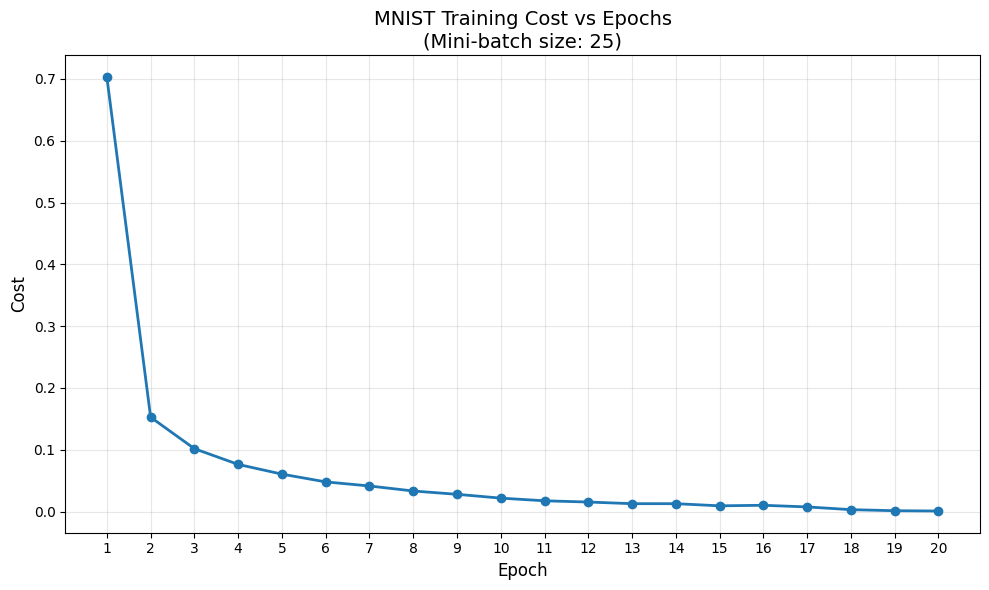

Final cost: 0.0008
Initial cost: 0.7030
Cost reduction: 99.9%


In [ ]:

# Plot MNIST training curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), costs_MNIST, marker='o', linewidth=2)
plt.ylabel('Cost', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.title('MNIST Training Cost vs Epochs\n(Mini-batch size: 25)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, num_epochs + 1))
plt.tight_layout()
plt.show()

print(f"Final cost: {costs_MNIST[-1]:.4f}")
print(f"Initial cost: {costs_MNIST[0]:.4f}")
print(f"Cost reduction: {((costs_MNIST[0] - costs_MNIST[-1]) / costs_MNIST[0] * 100):.1f}%")
